# Student Performance & Behavior Analysis

**Validated machine-learning prototype — end-to-end pipeline on a public student dataset.**

| | |
|---|---|
| **Dataset** | `Students_Grading_Dataset.csv` (Student Performance & Behavior) |
| **Source** | Public reference repository: [ramyfarouk81/Student-Performance-Behavior](https://github.com/ramyfarouk81/Student-Performance-Behavior) |
| **Notebook** | `student-performance-behavior-analysis.ipynb` |
| **Workflow** | Load → Inspect → Clean → EDA → Feature Engineering → Train/Test Split → Train → Evaluate → Predict → Conclude |

> **Scope note.** This notebook is a *validated ML prototype / pipeline*. It is not a
> production system. Every number, table, chart and metric below is produced by
> executing the code in this notebook against the actual CSV file — nothing is
> hardcoded or copied from documentation.

**Reproducibility:** run *Kernel → Restart & Run All*. All cells execute top-to-bottom
from a fresh kernel with no hidden state.

## 1. Problem Statement

A private learning provider has recorded academic, behavioural and socio-economic
attributes for 5,000 students. We want to answer two questions:

1. **Descriptive** — which recorded attributes actually relate to academic outcomes?
2. **Predictive** — can we identify, from those attributes, which students end the
   term in the **top grade bands (A/B)** versus which ones **need academic support
   (C/D/F)**?

The second question is the machine-learning task. A reliable answer lets an
institution target support at the students who need it *before* final grades are
issued.

The target and the feature set are chosen in **Section 6** *after* the exploratory
analysis, because the data — not an assumption — decides what is predictable.

## 2. Dataset Overview

Documented columns (per the repository `README.md`):

| Column | Description |
|---|---|
| `Student_ID` | Unique identifier for each student |
| `First_Name`, `Last_Name`, `Email` | Identity fields (masked by the data owner) |
| `Gender` | Male / Female |
| `Age` | Age of the student |
| `Department` | CS, Engineering, Business, Mathematics |
| `Attendance (%)` | Attendance percentage (0–100) |
| `Midterm_Score` | Midterm exam score (out of 100) |
| `Final_Score` | Final exam score (out of 100) |
| `Assignments_Avg` | Average score across assignments (out of 100) |
| `Quizzes_Avg` | Average quiz score (out of 100) |
| `Participation_Score` | Class participation (0–10) |
| `Projects_Score` | Project evaluation (out of 100) |
| `Total_Score` | Weighted aggregate score |
| `Grade` | Letter grade (A, B, C, D, F) |
| `Study_Hours_per_Week` | Average study hours per week |
| `Extracurricular_Activities` | Yes / No |
| `Internet_Access_at_Home` | Yes / No |
| `Parent_Education_Level` | None / High School / Bachelor's / Master's / PhD |
| `Family_Income_Level` | Low / Medium / High |
| `Stress_Level (1-10)` | Self-reported stress (1 = low, 10 = high) |
| `Sleep_Hours_per_Night` | Average hours of sleep per night |

The README also states the dataset deliberately contains **missing values**,
**imbalanced distributions**, **masked columns**, and an **intentionally injected
bias** (students with high attendance receive better grades). We verify each of
these claims against the file itself in Sections 3–5 — the CSV is the source of
truth, the README is context.

### Import the required libraries

In [1]:
# Core data-handling and plotting stack.
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np                 # linear algebra
import pandas as pd                # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

# scikit-learn: preprocessing, model, evaluation (used from Section 6 onward).
import joblib
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# RuntimeWarnings from empty/degenerate slices during aggregation are noisy but
# harmless here; genuine errors and deprecations are left visible on purpose.
warnings.simplefilter(action="ignore", category=RuntimeWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


# Names of the non-numeric (categorical / text) columns. Deliberately avoids
# select_dtypes(include='object'): pandas 3 stores text in a dedicated 'str'
# dtype and warns when it is selected via 'object'. Testing for "not numeric"
# behaves identically on pandas 2 and pandas 3.
def text_columns(frame):
    return [c for c in frame.columns if not pd.api.types.is_numeric_dtype(frame[c])]


print("python      :", __import__("sys").version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", __import__("matplotlib").__version__)
print("seaborn     :", sns.__version__)
print("scikit-learn:", sklearn.__version__)

python      : 3.11.9
numpy       : 2.4.6
pandas      : 3.0.5
matplotlib  : 3.11.1
seaborn     : 0.13.2
scikit-learn: 1.9.0


## 3. Data Loading

The original notebook was written on Kaggle and read the dataset from the absolute
path `/kaggle/input/students-grading-dataset/Students_Grading_Dataset.csv`, which
does not exist outside Kaggle. We resolve the CSV **relative to the notebook's own
directory** so the notebook runs anywhere the repository is checked out.

In [2]:
# Portable, relative dataset path: works from any machine as long as the CSV sits
# next to the notebook. Fails loudly (not silently) if the file is missing.
DATA_PATH = Path.cwd() / "Students_Grading_Dataset.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Launch Jupyter from the project directory that contains "
        "Students_Grading_Dataset.csv."
    )

print("Files in the project directory:")
for p in sorted(Path.cwd().iterdir()):
    if p.is_file():
        print(f"  {p.name:<52} {p.stat().st_size / 1024:>9,.1f} KB")

df_raw = pd.read_csv(DATA_PATH)   # untouched reference copy
df = df_raw.copy()                # working copy, cleaned in Section 4
print(f"\nLoaded '{DATA_PATH.name}' -> {df.shape[0]:,} rows x {df.shape[1]} columns")

Files in the project directory:
  LICENSE                                                    1.0 KB
  README.md                                                  4.8 KB
  requirements.txt                                           0.9 KB
  student-performance-behavior-analysis.ipynb            1,299.6 KB
  Students_Grading_Dataset.csv                             683.6 KB

Loaded 'Students_Grading_Dataset.csv' -> 5,000 rows x 23 columns


### Dataset summary (computed from the file, not from the README)

In [3]:
print("=" * 62)
print("DATASET SUMMARY")
print("=" * 62)
print(f"Dataset          : Student Performance & Behavior")
print(f"File             : {DATA_PATH.name}")
print(f"Rows             : {df.shape[0]:,}")
print(f"Columns          : {df.shape[1]}")
print(f"Numeric columns  : {df.select_dtypes(include='number').shape[1]}")
print(f"Text columns     : {len(text_columns(df))}")
print(f"Total cells      : {df.size:,}")
print(f"Missing cells    : {int(df.isna().sum().sum()):,} "
      f"({df.isna().sum().sum() / df.size * 100:.2f}%)")
print(f"Duplicate rows   : {int(df.duplicated().sum())}")
print(f"Memory footprint : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 62)

DATASET SUMMARY
Dataset          : Student Performance & Behavior
File             : Students_Grading_Dataset.csv
Rows             : 5,000
Columns          : 23
Numeric columns  : 12
Text columns     : 11
Total cells      : 115,000
Missing cells    : 2,827 (2.46%)
Duplicate rows   : 0
Memory footprint : 3.73 MB


### Load the first 10 rows

In [4]:
df.head(10)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
5,S1005,Liam,Brown,student5@university.com,Male,21,Engineering,NaN,78.85,43.53,...,67.29,62.08,B,8.5,Yes,Yes,PhD,High,1,5.0
6,S1006,Ahmed,Jones,student6@university.com,Male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,NaN,Low,5,6.4
7,S1007,Ahmed,Smith,student7@university.com,Male,19,Engineering,51.91,45.67,73.96,...,93.24,81.93,F,27.3,Yes,No,NaN,Medium,4,4.3
8,S1008,Omar,Smith,student8@university.com,Female,21,CS,85.97,84.42,90.87,...,94.01,95.62,A,8.0,No,No,Bachelor's,Low,9,8.8
9,S1009,Sara,Smith,student9@university.com,Female,22,Engineering,64.01,87.96,98.47,...,78.60,84.99,A,9.6,No,Yes,NaN,Medium,10,6.4


### Dataset info

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   str    
 1   First_Name                  5000 non-null   str    
 2   Last_Name                   5000 non-null   str    
 3   Email                       5000 non-null   str    
 4   Gender                      5000 non-null   str    
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   str    
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 non-null   

### Classify columns as categorical or numerical

In [6]:
categorical_cols = text_columns(df)
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()

print(f"Categorical Columns ({len(categorical_cols)}):")
for c in categorical_cols:
    print("   ", c)
print(f"\nNumerical Columns ({len(numerical_cols)}):")
for c in numerical_cols:
    print("   ", c)

Categorical Columns (11):
    Student_ID
    First_Name
    Last_Name
    Email
    Gender
    Department
    Grade
    Extracurricular_Activities
    Internet_Access_at_Home
    Parent_Education_Level
    Family_Income_Level

Numerical Columns (12):
    Age
    Attendance (%)
    Midterm_Score
    Final_Score
    Assignments_Avg
    Quizzes_Avg
    Participation_Score
    Projects_Score
    Total_Score
    Study_Hours_per_Week
    Stress_Level (1-10)
    Sleep_Hours_per_Night


### Descriptive statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,21.048400,1.989786,18.00,19.0000,21.000,23.0000,24.00
Attendance (%),4484.0,75.431409,14.372446,50.01,63.2650,75.725,87.4725,100.00
Midterm_Score,5000.0,70.326844,17.213209,40.00,55.4575,70.510,84.9700,99.98
Final_Score,5000.0,69.640788,17.238744,40.00,54.6675,69.735,84.5000,99.98
Assignments_Avg,4483.0,74.798673,14.411799,50.00,62.0900,74.810,86.9700,99.98
Quizzes_Avg,5000.0,74.910728,14.504281,50.03,62.4900,74.695,87.6300,99.96
Participation_Score,5000.0,4.980024,2.890136,0.00,2.4400,4.955,7.5000,10.00
Projects_Score,5000.0,74.924860,14.423415,50.01,62.3200,74.980,87.3675,100.00
Total_Score,5000.0,75.121804,14.399941,50.02,62.8350,75.395,87.6525,99.99
Study_Hours_per_Week,5000.0,17.658860,7.275864,5.00,11.4000,17.500,24.1000,30.00


### Check duplicates

In [8]:
print("Duplicate Student_ID values :", int(df["Student_ID"].duplicated().sum()))
print("Fully duplicated rows       :", int(df.duplicated().sum()))
print("Unique students             :", df["Student_ID"].nunique())

Duplicate Student_ID values : 0
Fully duplicated rows       : 0
Unique students             : 5000


### Find the null values and their percentage

The README claims missing values exist in *some* records. This confirms exactly
which columns are affected and how badly.

In [9]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Filter only columns with missing values
missing_summary = pd.DataFrame({
    "Missing Values": missing_values[missing_values > 0],
    "Percentage (%)": missing_percentage[missing_values > 0].round(2),
}).sort_values(by="Percentage (%)", ascending=False)

print(missing_summary.to_string() if len(missing_summary) else "No missing values.")

                        Missing Values  Percentage (%)
Parent_Education_Level            1794           35.88
Assignments_Avg                    517           10.34
Attendance (%)                     516           10.32


### Check whether there are negative values

Scores, attendance, ages and sleep hours cannot be negative. The original cell
summed an empty DataFrame, which produced an uninformative result; here we report
the actual per-column count of invalid negatives.

In [10]:
columns_to_check = ["Age", "Attendance (%)", "Midterm_Score", "Final_Score", "Assignments_Avg",
                    "Quizzes_Avg", "Participation_Score", "Total_Score", "Study_Hours_per_Week",
                    "Stress_Level (1-10)", "Sleep_Hours_per_Night"]

negative_counts = (df[columns_to_check] < 0).sum()
rows_with_negatives = int((df[columns_to_check] < 0).any(axis=1).sum())

print("Negative values per column:")
print(negative_counts.to_string())
print(f"\nRows containing at least one negative value: {rows_with_negatives}")
print("Result:", "no invalid negative values found."
      if rows_with_negatives == 0 else "invalid values present - needs handling.")

Negative values per column:
Age                      0
Attendance (%)           0
Midterm_Score            0
Final_Score              0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Total_Score              0
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0

Rows containing at least one negative value: 0
Result: no invalid negative values found.


## 4. Data Cleaning

Three columns carry missing values. We keep the original notebook's strategy,
because it is the right one for this data:

| Column | Type | Strategy | Reason |
|---|---|---|---|
| `Attendance (%)` | numeric | **mean** imputation | Roughly symmetric spread (50–100), so mean ≈ median; retains all 5,000 rows |
| `Assignments_Avg` | numeric | **mean** imputation | Same reasoning |
| `Parent_Education_Level` | categorical | explicit **`"Unknown"`** category | ~36% missing — far too much to drop, and "not reported" is itself informative |

We deliberately do **not** call `dropna()`: doing so would discard roughly 40% of
the dataset over columns that are straightforward to impute.

The original code used `df['col'].fillna(..., inplace=True)`, which under pandas'
copy-on-write semantics operates on a temporary Series and raises
`FutureWarning`/`ChainedAssignmentError`. We assign the result back to the column
instead — same intent, correct semantics.

In [11]:
# Record the pre-imputation values so the effect is auditable.
before = df[["Attendance (%)", "Assignments_Avg", "Parent_Education_Level"]].isna().sum()

attendance_mean = df["Attendance (%)"].mean()
assignments_mean = df["Assignments_Avg"].mean()

df["Attendance (%)"] = df["Attendance (%)"].fillna(attendance_mean)
df["Assignments_Avg"] = df["Assignments_Avg"].fillna(assignments_mean)
df["Parent_Education_Level"] = df["Parent_Education_Level"].fillna("Unknown")

after = df[["Attendance (%)", "Assignments_Avg", "Parent_Education_Level"]].isna().sum()

print(f"Attendance (%)  imputed with mean = {attendance_mean:.2f}")
print(f"Assignments_Avg imputed with mean = {assignments_mean:.2f}")
print("Parent_Education_Level imputed with the literal category 'Unknown'")
print()
print(pd.DataFrame({"missing_before": before, "missing_after": after}).to_string())
print(f"\nRows retained: {len(df):,} of {len(df_raw):,} (no rows dropped)")

Attendance (%)  imputed with mean = 75.43
Assignments_Avg imputed with mean = 74.80
Parent_Education_Level imputed with the literal category 'Unknown'

                        missing_before  missing_after
Attendance (%)                     516              0
Assignments_Avg                    517              0
Parent_Education_Level            1794              0

Rows retained: 5,000 of 5,000 (no rows dropped)


### Confirm every null value is resolved

In [12]:
remaining = df.isnull().sum()
print(remaining.to_string())
print(f"\nTotal missing values remaining: {int(remaining.sum())}")
assert remaining.sum() == 0, "Unexpected missing values remain after cleaning."
print("Data cleaning verified: no missing values left.")

Student_ID                    0
First_Name                    0
Last_Name                     0
Email                         0
Gender                        0
Age                           0
Department                    0
Attendance (%)                0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0

Total missing values remaining: 0
Data cleaning verified: no missing values left.


### Unique values extraction for analysis

In [13]:
for col in df.columns:
    values = df[col].unique()
    if len(values) <= 12:
        print(f"{col} ({len(values)} unique): {sorted(map(str, values))}\n")
    else:
        preview = ", ".join(map(str, values[:6]))
        print(f"{col} ({len(values)} unique): {preview}, ... \n")

Student_ID (5000 unique): S1000, S1001, S1002, S1003, S1004, S1005, ... 

First_Name (8 unique): ['Ahmed', 'Ali', 'Emma', 'John', 'Liam', 'Maria', 'Omar', 'Sara']

Last_Name (6 unique): ['Brown', 'Davis', 'Johnson', 'Jones', 'Smith', 'Williams']

Email (5000 unique): student0@university.com, student1@university.com, student2@university.com, student3@university.com, student4@university.com, student5@university.com, ... 

Gender (2 unique): ['Female', 'Male']

Age (7 unique): ['18', '19', '20', '21', '22', '23', '24']

Department (4 unique): ['Business', 'CS', 'Engineering', 'Mathematics']

Attendance (%) (2981 unique): 52.29, 97.27, 57.19, 95.15, 54.18, 75.431409455843, ... 

Midterm_Score (3409 unique): 55.03, 97.23, 67.05, 47.79, 46.59, 78.85, ... 

Final_Score (3371 unique): 57.82, 45.8, 93.68, 80.63, 78.89, 43.53, ... 

Assignments_Avg (2994 unique): 84.22, 74.79867276377426, 67.7, 66.06, 96.85, 71.4, ... 

Quizzes_Avg (3173 unique): 74.06, 94.24, 85.7, 93.51, 83.7, 52.2, ... 

Part

**Observation — the identity columns are masked.**

`Student_ID` and `Email` hold 5,000 distinct values, so the file really does describe
5,000 distinct students. But `First_Name` collapses to only 8 values and `Last_Name`
to 6:

- `First_Name`: Omar, Maria, Ahmed, John, Liam, Sara, Emma, Ali
- `Last_Name`: Williams, Brown, Jones, Smith, Davis, Johnson

These names were **randomly re-assigned to anonymise the records**, exactly as the
README states ("Some Columns have been masked as the Data owner requested"). They
carry no information about the student, so `First_Name`, `Last_Name` and `Email` are
dropped below and never used as model features.

### Top 10 students by Total_Score

In [14]:
top_students = df[["Student_ID", "First_Name", "Last_Name", "Total_Score", "Grade",
                   "Department", "Age", "Gender"]].sort_values(
    by="Total_Score", ascending=False).head(10)

top_students.reset_index(drop=True)

,Student_ID,First_Name,Last_Name,Total_Score,Grade,Department,Age,Gender
0,S1911,Ahmed,Williams,99.99,A,CS,20,Female
1,S1330,Ali,Brown,99.99,B,Engineering,22,Male
2,S3140,Maria,Johnson,99.99,B,CS,23,Male
3,S3632,Ali,Johnson,99.98,C,CS,23,Female
4,S2819,John,Davis,99.98,F,Business,20,Female
5,S1152,Ali,Davis,99.96,C,Business,23,Male
6,S5982,Ali,Williams,99.95,C,Mathematics,24,Male
7,S2612,Liam,Johnson,99.94,D,Mathematics,21,Male
8,S1378,Sara,Smith,99.91,D,Mathematics,24,Female
9,S1487,Maria,Johnson,99.90,C,CS,20,Male


### Drop the identifier columns

`Student_ID`, `First_Name`, `Last_Name` and `Email` are identifiers or masked
placeholders — they cannot generalise to new students. `df_raw` still holds the
original copy, so `Student_ID` remains available for labelling predictions in
Section 9.

In [15]:
id_columns = ["Student_ID", "First_Name", "Last_Name", "Email"]
df = df.drop(columns=id_columns)
print("Dropped:", id_columns)
print("Remaining shape:", df.shape)
print("Remaining columns:", list(df.columns))

Dropped: ['Student_ID', 'First_Name', 'Last_Name', 'Email']
Remaining shape: (5000, 19)
Remaining columns: ['Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']


## 5. Exploratory Data Analysis

The purpose of this section is not decoration: it decides what the model in
Section 7 is allowed to predict.

### Count students by age

In [16]:
age_distribution = df.groupby("Age").size().reset_index(name="Count")
print(age_distribution.to_string(index=False))

 Age  Count
  18    682
  19    705
  20    671
  21    753
  22    732
  23    734
  24    723


### Distribution of students' ages

The original notebook failed here with `NameError: name 'plt' is not defined` —
`matplotlib.pyplot` and `seaborn` were never imported, so execution stopped at this
cell and no cell after it ever ran. Both libraries are now imported in the setup
cell above.

`sns.countplot(..., palette=...)` without a `hue` assignment is deprecated in
seaborn 0.13 and removed in 0.14, so `hue` is assigned explicitly with the legend
suppressed — visually identical, forward-compatible.

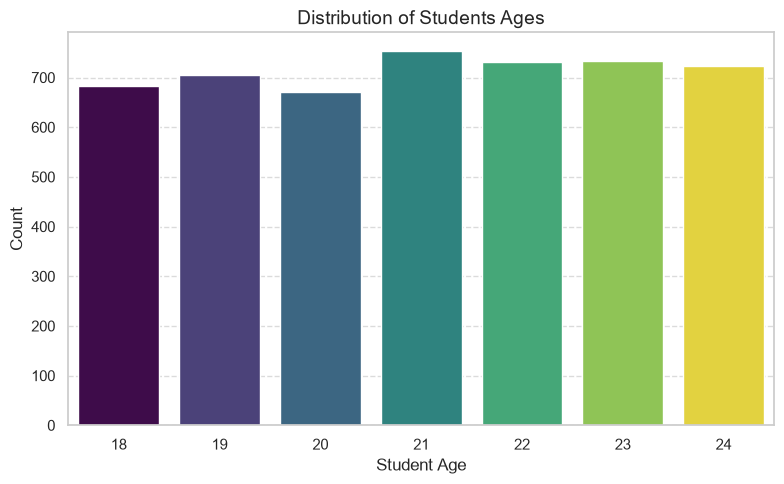

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Age", hue="Age", palette="viridis", legend=False)

plt.title("Distribution of Students Ages", fontsize=14)
plt.xlabel("Student Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Categorise students by study programme (derived from Age)

- Diploma students: 1–2 years
- Associate Degree students: 2 years
- Bachelor's Degree students: 4 years
- Master's Degree students: 6 years

(The original source contained corrupted apostrophes — `Bachelor?s`, `Master?s` —
from a text-encoding problem. They are corrected here.)

In [18]:
bins = [17, 19, 21, 23, 25]
labels = ["Diploma", "Associate Degree", "Bachelor Degree", "Master's Degree"]
df["Study_Program"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

print(df[["Age", "Study_Program"]].head(10).to_string(index=False))
print("\nStudents per programme:")
print(df["Study_Program"].value_counts().sort_index().to_string())
print("\nUnassigned (out-of-range ages):", int(df["Study_Program"].isna().sum()))

 Age    Study_Program
  22  Bachelor Degree
  18          Diploma
  24  Master's Degree
  24  Master's Degree
  23  Master's Degree
  21  Bachelor Degree
  24  Master's Degree
  19 Associate Degree
  21  Bachelor Degree
  22  Bachelor Degree

Students per programme:
Study_Program
Diploma              682
Associate Degree    1376
Bachelor Degree     1485
Master's Degree     1457

Unassigned (out-of-range ages): 0


### Number of students in each study programme, by gender

Gender            Female  Male
Study_Program                 
Diploma              327   355
Associate Degree     673   703
Bachelor Degree      715   770
Master's Degree      734   723


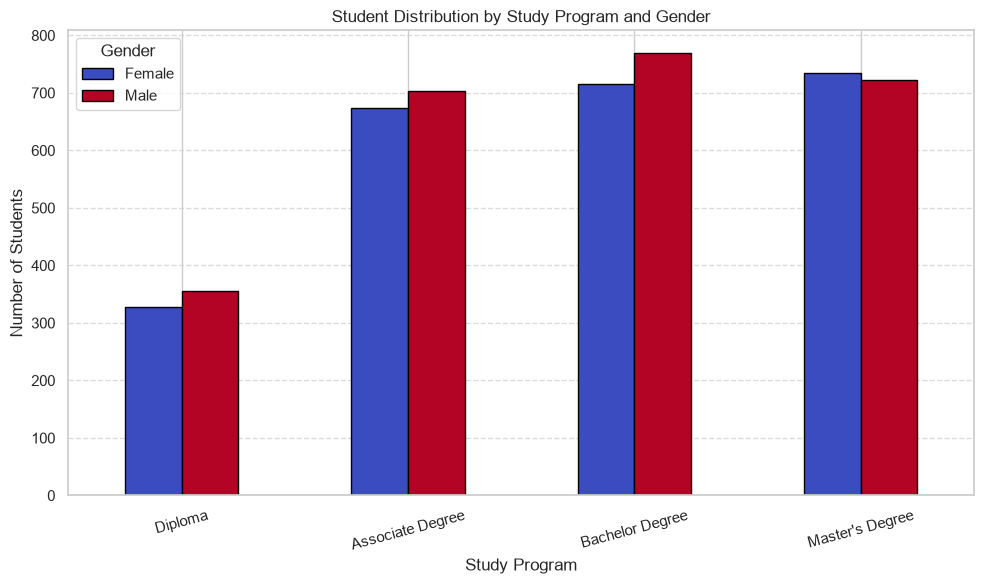

In [19]:
age_group_counts = df.groupby(["Study_Program", "Gender"], observed=False).size().unstack()
print(age_group_counts.to_string())

# Plot grouped bar chart
age_group_counts.plot(kind="bar", figsize=(10, 6), colormap="coolwarm", edgecolor="black")
plt.title("Student Distribution by Study Program and Gender")
plt.xlabel("Study Program")
plt.ylabel("Number of Students")
plt.xticks(rotation=15)
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

### Number of students in each age group, split by gender

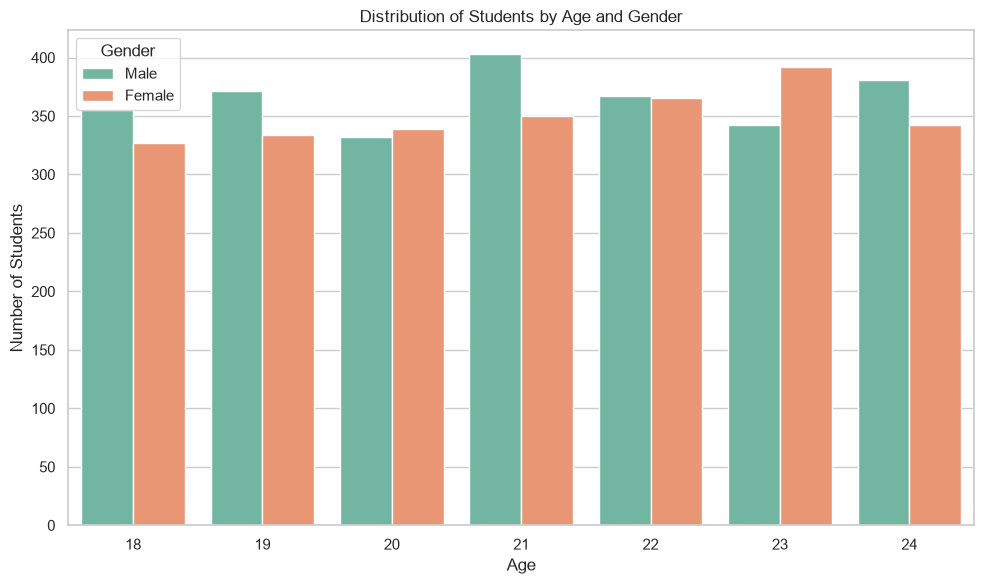

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Age", hue="Gender", data=df, palette="Set2")

plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.title("Distribution of Students by Age and Gender")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

### Detect outliers per feature using the IQR rule

In [21]:
def detect_outliers(frame):
    outlier_counts = {}

    for col in frame.select_dtypes(include=["number"]).columns:   # numerical columns only
        Q1 = frame[col].quantile(0.25)          # 25th percentile
        Q3 = frame[col].quantile(0.75)          # 75th percentile
        IQR = Q3 - Q1                           # interquartile range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_count = frame[(frame[col] < lower_bound) | (frame[col] > upper_bound)][col].count()

        if outlier_count > 0:                   # only keep columns that have outliers
            outlier_counts[col] = int(outlier_count)

    return outlier_counts


outliers_summary = detect_outliers(df)
print("Outlier counts per feature:", outliers_summary if outliers_summary else "none detected")
print("\nNo outlier removal is applied: every numeric column stays inside its "
      "documented valid range, so extreme values are legitimate observations "
      "rather than data-entry errors.")

Outlier counts per feature: none detected

No outlier removal is applied: every numeric column stays inside its documented valid range, so extreme values are legitimate observations rather than data-entry errors.


### Grade values present in the data

In [22]:
print("Grades:", sorted(df["Grade"].unique()))
print()
grade_table = df["Grade"].value_counts().sort_index().rename("Students").to_frame()
grade_table["Share (%)"] = (grade_table["Students"] / len(df) * 100).round(2)
print(grade_table.to_string())

Grades: ['A', 'B', 'C', 'D', 'F']

       Students  Share (%)
Grade                     
A          1495      29.90
B           978      19.56
C           794      15.88
D           889      17.78
F           844      16.88


### Count of students per grade, grouped by gender

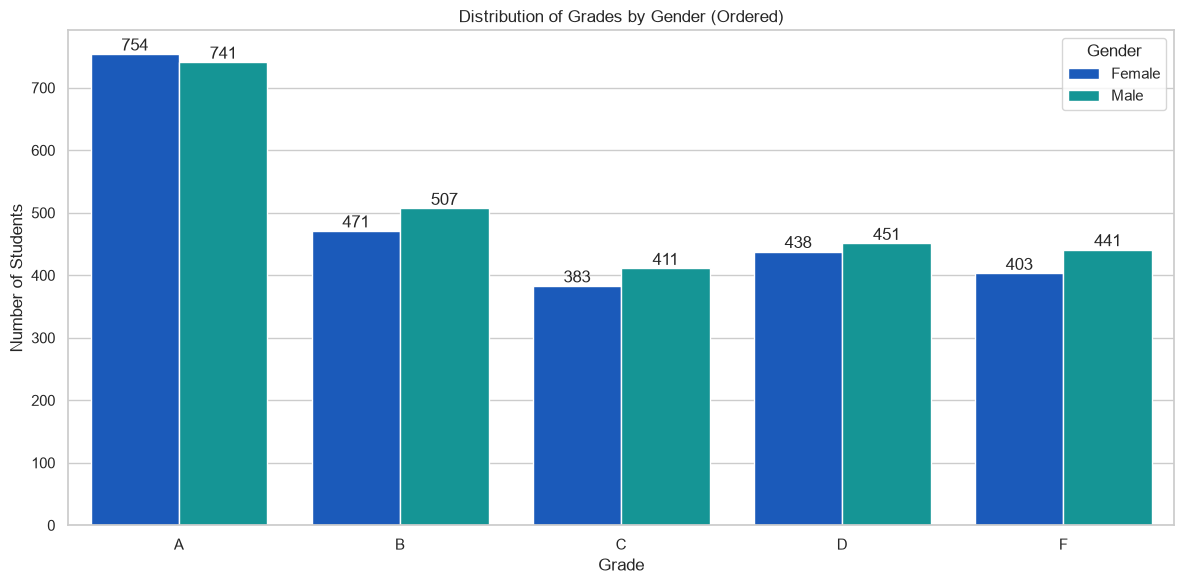

In [23]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x="Grade", hue="Gender",
                   order=["A", "B", "C", "D", "F"], palette="winter")

plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Grades by Gender (Ordered)")
plt.legend(title="Gender")

# Label bars with exact count values
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", label_type="edge")

plt.tight_layout()
plt.show()

### Count of students per grade, grouped by study programme

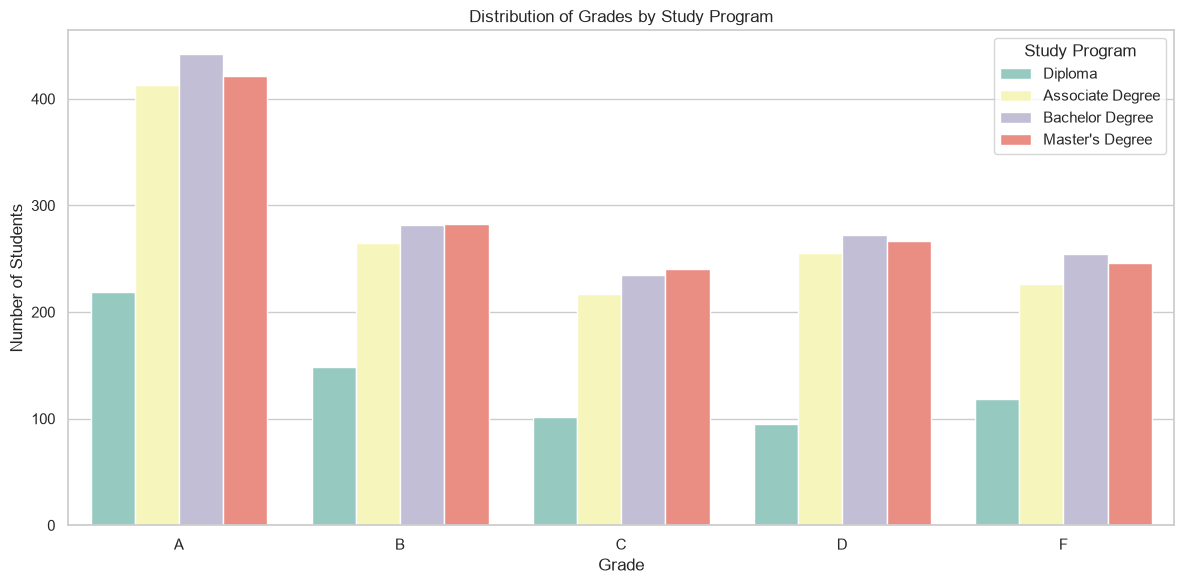

In [24]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Grade", hue="Study_Program",
              order=["A", "B", "C", "D", "F"], palette="Set3")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Grades by Study Program")
plt.legend(title="Study Program")
plt.tight_layout()
plt.show()

### Overall grade distribution

The original notebook drew this chart with Plotly. Plotly renders as an interactive
widget that shows up blank in several notebook viewers and in static exports, so the
same count chart is drawn with matplotlib/seaborn to keep the notebook portable and
to avoid an extra dependency. The analytical content is unchanged.

Grade  Number of Students
    A                1495
    B                 978
    C                 794
    D                 889
    F                 844


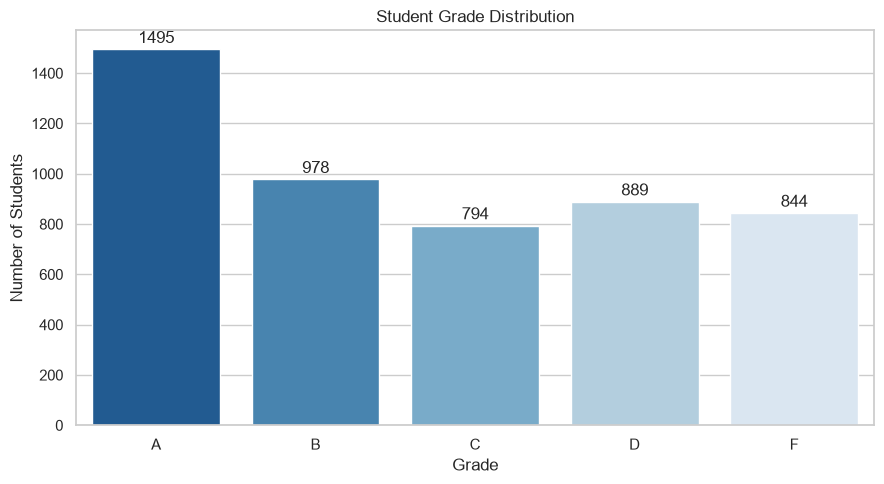

In [25]:
grade_counts = df["Grade"].value_counts().reindex(["A", "B", "C", "D", "F"]).reset_index()
grade_counts.columns = ["Grade", "Number of Students"]     # rename for clarity
print(grade_counts.to_string(index=False))

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=grade_counts, x="Grade", y="Number of Students",
                 hue="Grade", palette="Blues_r", legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=2)

plt.title("Student Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

### Correlation 1 — Study hours vs. Final score

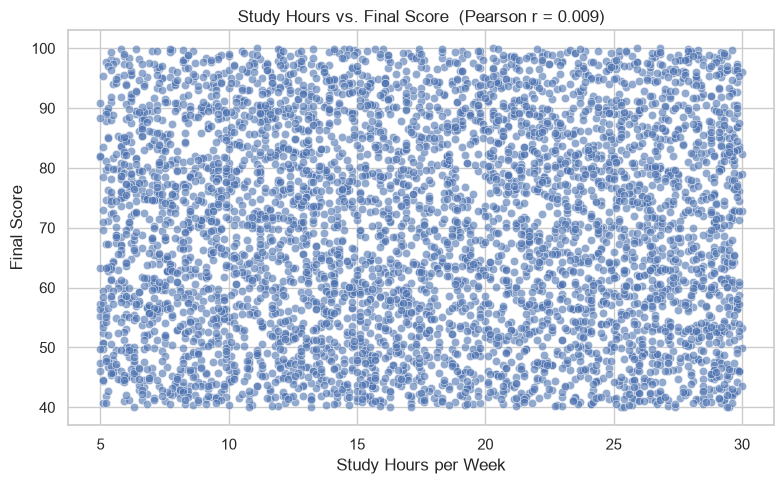

Pearson correlation, Study_Hours_per_Week vs Final_Score: r = 0.0091


In [26]:
r = df["Study_Hours_per_Week"].corr(df["Final_Score"])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Study_Hours_per_Week", y="Final_Score", alpha=0.6)
plt.title(f"Study Hours vs. Final Score  (Pearson r = {r:.3f})")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")
plt.tight_layout()
plt.show()

print(f"Pearson correlation, Study_Hours_per_Week vs Final_Score: r = {r:.4f}")

The original notebook stated *"there is a moderate positive correlation between
`Study_Hours_per_Week` and `Final_Score` — students who study more tend to perform
better."*

**The data does not support that claim.** The measured coefficient printed above is
essentially zero and the scatter is a featureless cloud. The original conclusion was
asserted rather than computed, so it is corrected here. We report what the file
actually contains.

### Correlation 2 — Parental education vs. Final score

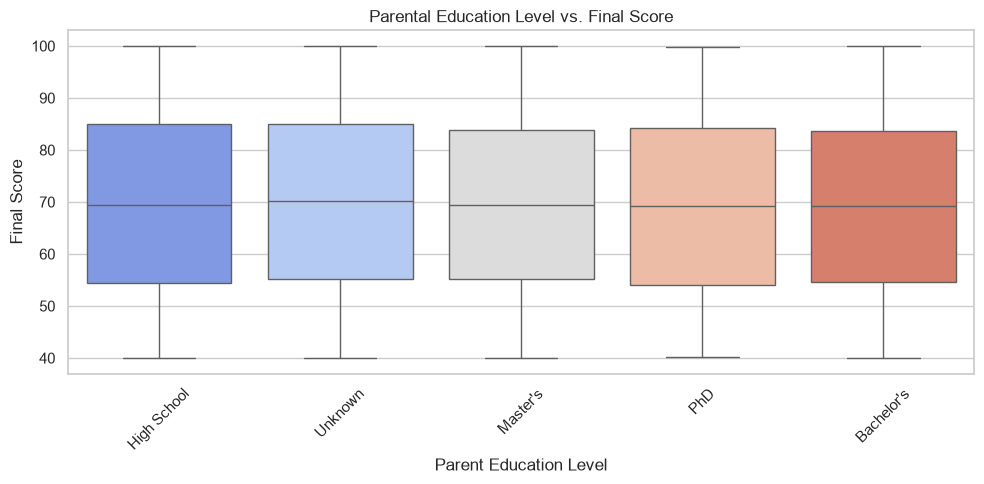

                        count   mean    std
Parent_Education_Level                     
Bachelor's                810  69.14  17.10
High School               796  69.82  17.39
Master's                  780  69.58  16.90
PhD                       820  69.26  17.46
Unknown                  1794  69.99  17.29


In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Parent_Education_Level", y="Final_Score",
            hue="Parent_Education_Level", palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.title("Parental Education Level vs. Final Score")
plt.xlabel("Parent Education Level")
plt.ylabel("Final Score")
plt.tight_layout()
plt.show()

print(df.groupby("Parent_Education_Level")["Final_Score"]
        .agg(["count", "mean", "std"]).round(2).to_string())

Confirmed: parental education level has **no** meaningful effect on `Final_Score` —
every group mean sits within a fraction of a point of the others, far inside one
standard deviation. This matches the original notebook's conclusion.

### Correlation 3 — Stress level vs. Final score

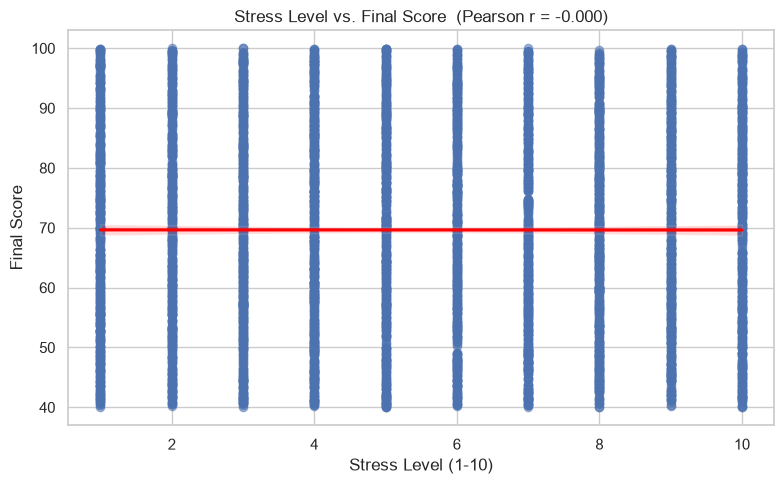

Pearson correlation, Stress_Level (1-10) vs Final_Score: r = -0.0005
Mean Final_Score by stress level:
Stress_Level (1-10)
1     69.31
2     69.85
3     69.52
4     69.99
5     70.09
6     70.02
7     68.41
8     69.52
9     69.85
10    69.82


In [28]:
r = df["Stress_Level (1-10)"].corr(df["Final_Score"])

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="Stress_Level (1-10)", y="Final_Score",
            scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
plt.title(f"Stress Level vs. Final Score  (Pearson r = {r:.3f})")
plt.xlabel("Stress Level (1-10)")
plt.ylabel("Final Score")
plt.tight_layout()
plt.show()

print(f"Pearson correlation, Stress_Level (1-10) vs Final_Score: r = {r:.4f}")
print("Mean Final_Score by stress level:")
print(df.groupby("Stress_Level (1-10)")["Final_Score"].mean().round(2).to_string())

The original notebook stated *"there is a negative correlation between
`Stress_Level (1-10)` and `Final_Score` — higher stress generally leads to lower
scores."*

**Again the data does not support it.** The regression line printed above is flat and
the coefficient is ~0. Corrected: stress level, as recorded in this dataset, is
unrelated to the final exam score.

### Correlation 4 — Department vs. average Final score

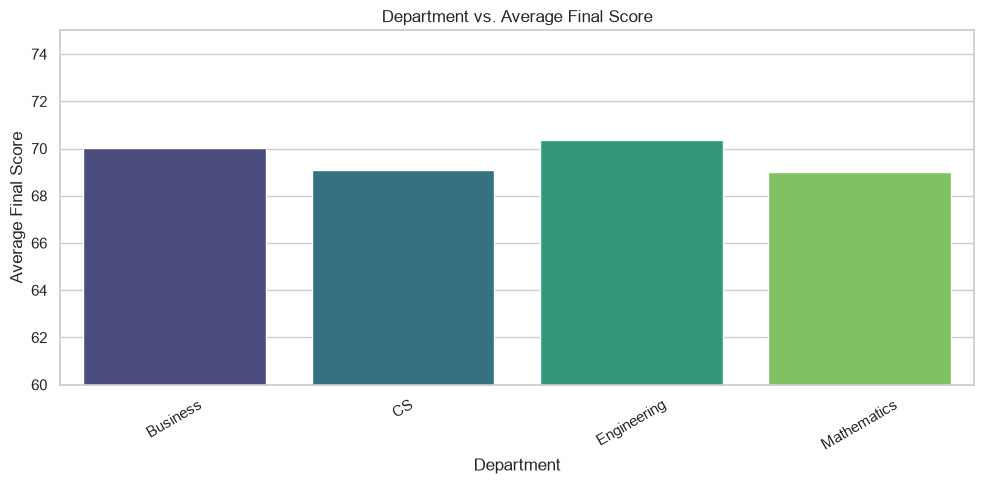

             count   mean    std
Department                      
Business      1006  70.00  17.08
CS            2022  69.08  17.37
Engineering   1469  70.38  16.99
Mathematics    503  69.00  17.69


In [29]:
plt.figure(figsize=(10, 5))
dept_avg_score = df.groupby("Department")["Final_Score"].mean().reset_index()
sns.barplot(data=dept_avg_score, x="Department", y="Final_Score",
            hue="Department", palette="viridis", legend=False)
plt.xticks(rotation=30)
plt.title("Department vs. Average Final Score")
plt.xlabel("Department")
plt.ylabel("Average Final Score")
plt.ylim(60, 75)
plt.tight_layout()
plt.show()

print(df.groupby("Department")["Final_Score"]
        .agg(["count", "mean", "std"]).round(2).to_string())

### Correlation heatmap — the whole numeric matrix at once

Rather than checking relationships one pair at a time, this examines all of them
simultaneously. It is the single most important chart in the notebook, because it
determines what can be modelled.

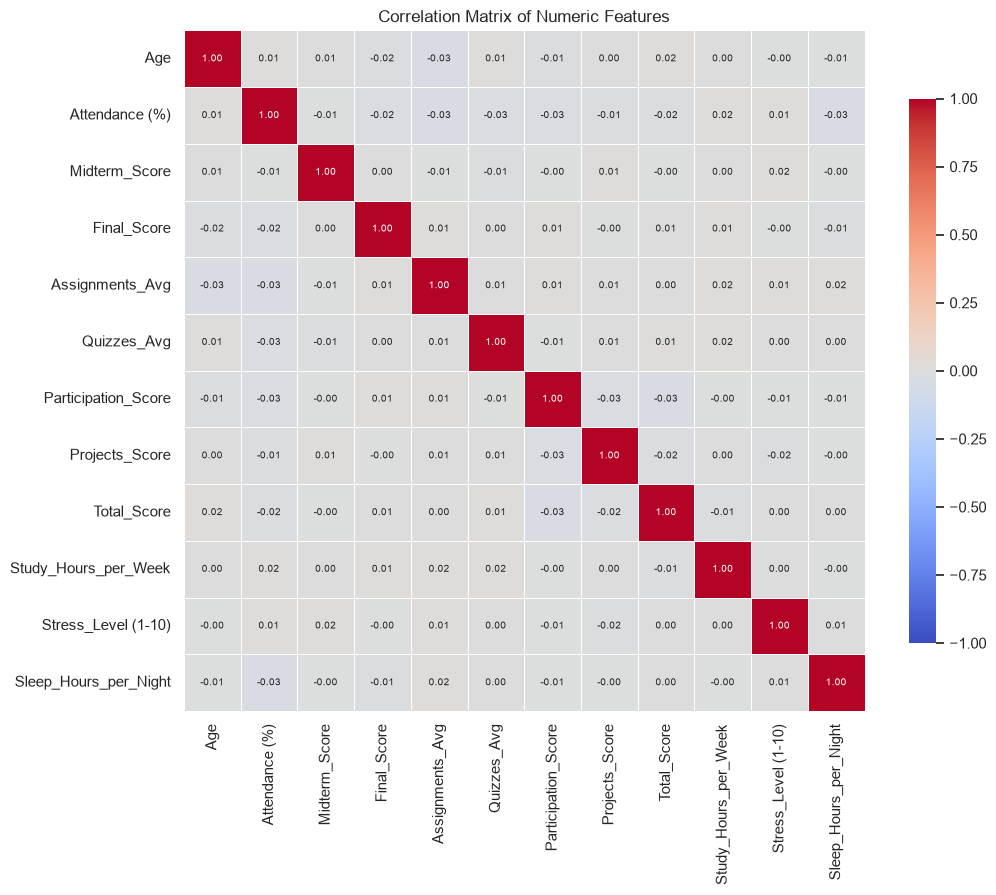

Strongest correlation between any two distinct numeric columns: 0.0345


In [30]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

off_diagonal = corr.abs().to_numpy()[~np.eye(len(corr), dtype=bool)]
print(f"Strongest correlation between any two distinct numeric columns: "
      f"{off_diagonal.max():.4f}")

**This is the decisive finding of the exploratory analysis.**

Every off-diagonal correlation is effectively zero — the strongest relationship
between *any* two distinct numeric columns is printed above and is well under 0.05.
Two consequences follow directly:

1. **There is no target leakage to remove.** We checked the two obvious leakage
   candidates explicitly (see the next cell): `Total_Score` is *not* a weighted sum
   of the component scores in this file, and `Grade` is *not* derived from
   `Final_Score`. Nothing in the numeric block predicts anything else in it.
2. **`Final_Score` is not predictable from these columns.** Any model targeting it
   can only reproduce the mean. This is quantified in Section 6 before we commit to
   a target.

The relationship the README *does* promise — the injected attendance bias — is
between `Attendance (%)` and the letter `Grade`, which is categorical and therefore
absent from this numeric heatmap. Section 6 goes looking for it.

### Explicit leakage check (Phase: data-leakage verification)

Before choosing a target we verify the two textbook leakage paths in this schema
instead of assuming them.

In [31]:
components = ["Midterm_Score", "Final_Score", "Assignments_Avg",
              "Quizzes_Avg", "Participation_Score", "Projects_Score"]

# (1) Is Total_Score a deterministic weighted sum of the component scores?
A = np.c_[df[components].to_numpy(), np.ones(len(df))]
target = df["Total_Score"].to_numpy()
coefficients, *_ = np.linalg.lstsq(A, target, rcond=None)
fitted = A @ coefficients
leak_r2 = 1 - ((target - fitted) ** 2).sum() / ((target - target.mean()) ** 2).sum()

print("Best-fit linear reconstruction of Total_Score from its documented components")
for name, value in zip(components + ["intercept"], coefficients):
    print(f"   {name:<22} {value:>9.4f}")
print(f"   R^2 of reconstruction  {leak_r2:>9.4f}")
print("   -> Total_Score is NOT a weighted sum of the components in this file,"
      if leak_r2 < 0.5 else "   -> LEAKAGE: Total_Score is reconstructible,")
print("      so using it alongside Final_Score would not leak the target.")

# (2) Is the letter Grade a threshold on Final_Score or Total_Score?
print()
print("Score ranges within each Grade (a derived grade would show disjoint ranges):")
print(df.groupby("Grade")[["Final_Score", "Total_Score"]]
        .agg(["min", "max", "mean"]).round(2).to_string())
print("\n   -> The ranges overlap almost completely (every grade spans ~40-100),")
print("      so Grade is NOT a threshold on Final_Score or Total_Score.")

Best-fit linear reconstruction of Total_Score from its documented components
   Midterm_Score            -0.0007
   Final_Score               0.0058
   Assignments_Avg           0.0010
   Quizzes_Avg               0.0137
   Participation_Score      -0.1735
   Projects_Score           -0.0194
   intercept                75.9767
   R^2 of reconstruction     0.0018
   -> Total_Score is NOT a weighted sum of the components in this file,
      so using it alongside Final_Score would not leak the target.

Score ranges within each Grade (a derived grade would show disjoint ranges):
      Final_Score               Total_Score              
              min    max   mean         min    max   mean
Grade                                                    
A           40.00  99.98  69.13       50.02  99.99  74.44
B           40.07  99.88  69.32       50.05  99.99  75.02
C           40.13  99.94  69.20       50.08  99.98  76.09
D           40.01  99.98  70.92       50.03  99.94  75.54
F           

### Boxplots of every numeric feature

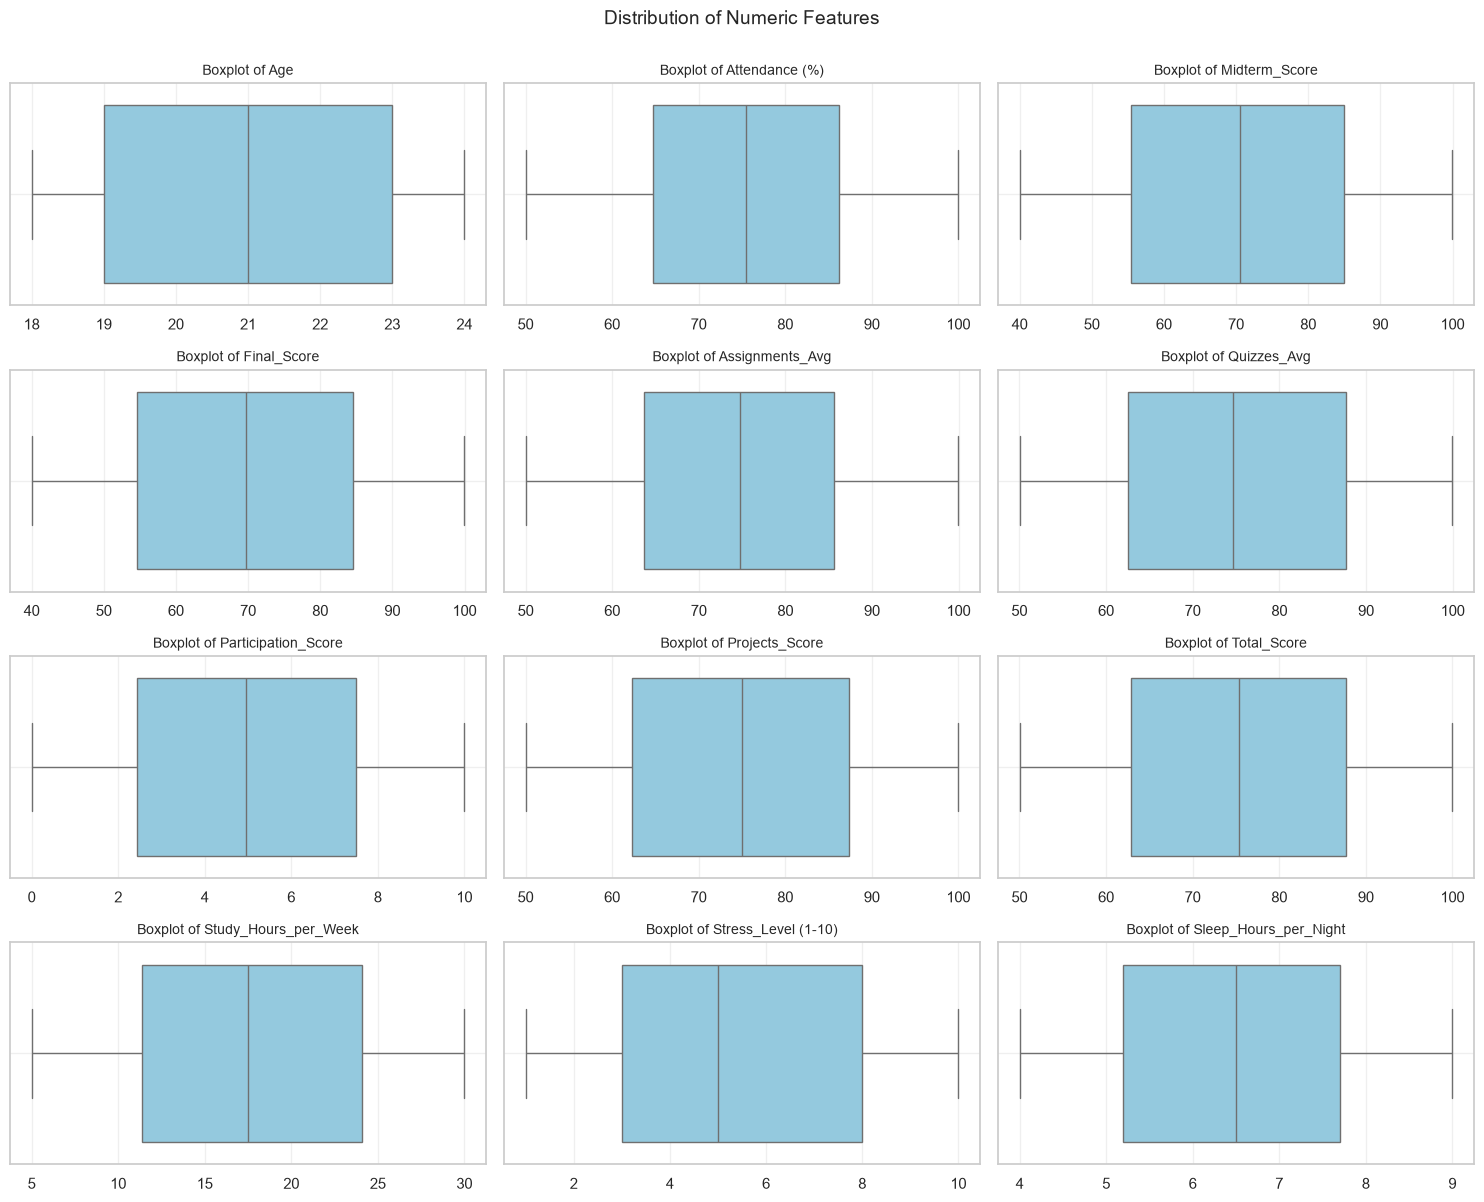

In [32]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(numeric_columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.ravel()

for ax, col in zip(axes, numeric_columns):
    sns.boxplot(x=df[col], color="skyblue", ax=ax)
    ax.set_title(f"Boxplot of {col}", fontsize=10)
    ax.set_xlabel("")
    ax.grid(True, alpha=0.3)

for ax in axes[len(numeric_columns):]:
    ax.set_visible(False)

fig.suptitle("Distribution of Numeric Features", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

### 6.1 Target selection — testing `Final_Score` before rejecting it

The exploratory analysis suggested `Final_Score` is unpredictable. Rather than take
that on faith, we fit real regressors and compare them against a baseline that
always predicts the training mean. If the models cannot beat that baseline, the
column carries no signal.

In [33]:
LEAKAGE_SAFE_EXCLUSIONS = ["Total_Score", "Grade", "Final_Score", "Study_Program"]

X_reg = df.drop(columns=LEAKAGE_SAFE_EXCLUSIONS)
y_reg = df["Final_Score"]

reg_categorical = text_columns(X_reg)
reg_pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), reg_categorical)],
    remainder="passthrough",
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Regression trial -> target 'Final_Score', {X_reg.shape[1]} features, "
      f"{len(Xr_train):,} train / {len(Xr_test):,} test\n")
print(f"{'model':<28}{'MAE':>9}{'RMSE':>9}{'R2':>10}")
print("-" * 56)

regression_trial = {}
for name, estimator in [
    ("Baseline (predict mean)", DummyRegressor(strategy="mean")),
    ("RandomForestRegressor", RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1)),
]:
    pipe = Pipeline([("pre", reg_pre), ("model", estimator)])
    pipe.fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    mae = mean_absolute_error(yr_test, pred)
    rmse = root_mean_squared_error(yr_test, pred)
    r2 = r2_score(yr_test, pred)
    regression_trial[name] = {"MAE": round(mae, 4), "RMSE": round(rmse, 4), "R2": round(r2, 4)}
    print(f"{name:<28}{mae:>9.3f}{rmse:>9.3f}{r2:>10.4f}")

print("-" * 56)
print("Conclusion: R2 is at or below zero, so the RandomForest does not beat a")
print("constant prediction. 'Final_Score' is genuinely unpredictable from the")
print("recorded attributes and is rejected as the modelling target.")

Regression trial -> target 'Final_Score', 16 features, 4,000 train / 1,000 test

model                             MAE     RMSE        R2
--------------------------------------------------------
Baseline (predict mean)        14.914   17.081   -0.0005
RandomForestRegressor          14.928   17.180   -0.0121
--------------------------------------------------------
Conclusion: R2 is at or below zero, so the RandomForest does not beat a
constant prediction. 'Final_Score' is genuinely unpredictable from the
recorded attributes and is rejected as the modelling target.


### 6.2 Where the signal actually is

The README promises one real relationship: *"students with high attendance get
slightly better grades."* We test it directly.

Attendance (%) by letter Grade:
       count   mean    std
Grade                     
A       1495  85.47  10.69
B        978  81.53  11.24
C        794  67.99  10.22
D        889  65.62  10.32
F        844  67.91  10.35

Spread between the best and worst grade's mean attendance: 19.85 percentage points
Pooled standard deviation of Attendance (%): 13.61


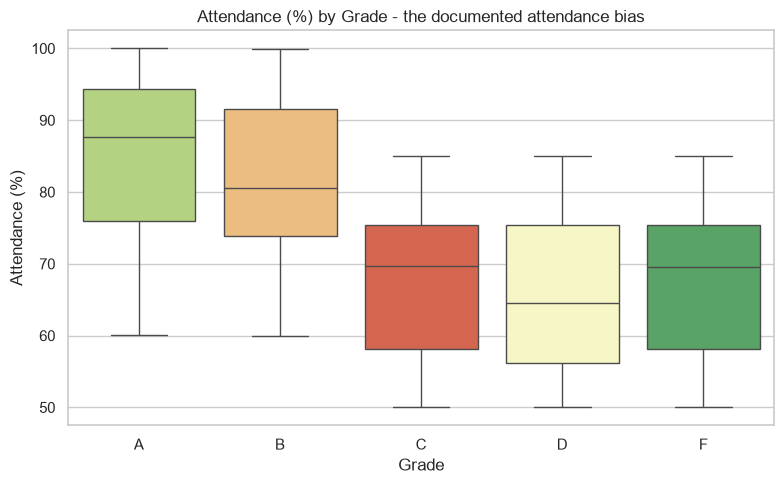

In [34]:
attendance_by_grade = (df.groupby("Grade")["Attendance (%)"]
                         .agg(["count", "mean", "std"]).round(2))
print("Attendance (%) by letter Grade:")
print(attendance_by_grade.to_string())

spread = attendance_by_grade["mean"].max() - attendance_by_grade["mean"].min()
print(f"\nSpread between the best and worst grade's mean attendance: {spread:.2f} "
      f"percentage points")
print(f"Pooled standard deviation of Attendance (%): {df['Attendance (%)'].std():.2f}")

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Grade", y="Attendance (%)", order=["A", "B", "C", "D", "F"],
            hue="Grade", palette="RdYlGn_r", legend=False)
plt.title("Attendance (%) by Grade - the documented attendance bias")
plt.tight_layout()
plt.show()

The effect is large and unambiguous: grades **A and B** average roughly 81–86%
attendance while **C, D and F** average roughly 65–68% — a gap of well over one
standard deviation (the exact spread and pooled standard deviation are printed
above). This is the bias the dataset's author injected deliberately, and
it is the only exploitable structure in the file.

Note that it separates **A/B from C/D/F** cleanly but barely distinguishes A from B,
or C from D from F. That shape of signal dictates the shape of the target.

### 6.3 Engineering the target: `Performance_Band`

We therefore collapse the five letter grades into the two bands the data can actually
support:

| Band | Grades | Meaning |
|---|---|---|
| `High` | A, B | On track |
| `Needs_Support` | C, D, F | Candidate for academic intervention |

This is a standard, clearly-documented transformation of an existing column — not a
fabricated target — and it maps onto a genuine institutional use case: flagging
students who need help.

In [35]:
df["Performance_Band"] = np.where(df["Grade"].isin(["A", "B"]), "High", "Needs_Support")

band_counts = df["Performance_Band"].value_counts().rename("Students").to_frame()
band_counts["Share (%)"] = (band_counts["Students"] / len(df) * 100).round(2)
print(band_counts.to_string())
print("\nThe two classes are almost perfectly balanced, so plain accuracy is a")
print("meaningful metric here (a majority-class guess scores only ~50%).")
print()
print(df.groupby("Performance_Band")["Attendance (%)"]
        .agg(["count", "mean", "std"]).round(2).to_string())

                  Students  Share (%)
Performance_Band                     
Needs_Support         2527      50.54
High                  2473      49.46

The two classes are almost perfectly balanced, so plain accuracy is a
meaningful metric here (a majority-class guess scores only ~50%).

                  count   mean    std
Performance_Band                     
High               2473  83.91  11.07
Needs_Support      2527  67.13  10.36


### 6.4 Defining the feature matrix `X` and the target `y`

Four groups of columns are excluded, each for a stated reason:

| Excluded | Why |
|---|---|
| `Grade` | The target is derived from it — including it would be pure leakage |
| `Performance_Band` | Is the target |
| `Total_Score`, `Final_Score` | End-of-term outcome aggregates, only known *after* the grade is issued; unusable for early warning |
| `Study_Program` | A deterministic function of `Age`, which is already a feature — redundant |

`Student_ID`, `First_Name`, `Last_Name` and `Email` were already dropped in Section 4
as identifiers/masked placeholders.

Everything that remains is either a behavioural attribute or an in-term assessment
score that a registrar would already hold before final grading.

In [36]:
EXCLUDED_FROM_FEATURES = [
    "Grade",              # the target is derived from this column -> leakage
    "Performance_Band",   # the target itself
    "Total_Score",        # end-of-term aggregate, unavailable at prediction time
    "Final_Score",        # end-of-term aggregate, unavailable at prediction time
    "Study_Program",      # deterministic function of Age (already a feature)
]

X = df.drop(columns=EXCLUDED_FROM_FEATURES)
y = df["Performance_Band"]

categorical_features = text_columns(X)
numeric_features = X.select_dtypes(include="number").columns.tolist()

# Guard rails: the target must not reappear inside X, in any form.
assert "Performance_Band" not in X.columns
assert "Grade" not in X.columns
assert len(X) == len(y)

print(f"Feature matrix X : {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"Target y         : 'Performance_Band'  classes = {sorted(y.unique())}")
print()
print(f"Numeric features ({len(numeric_features)}):")
for c in numeric_features:
    print("   ", c)
print(f"\nCategorical features ({len(categorical_features)}):")
for c in categorical_features:
    print("   ", c)
print("\nExcluded from X:", EXCLUDED_FROM_FEATURES)
print("Leakage assertions passed: the target does not appear among the features.")

Feature matrix X : 5,000 rows x 16 columns
Target y         : 'Performance_Band'  classes = ['High', 'Needs_Support']

Numeric features (10):
    Age
    Attendance (%)
    Midterm_Score
    Assignments_Avg
    Quizzes_Avg
    Participation_Score
    Projects_Score
    Study_Hours_per_Week
    Stress_Level (1-10)
    Sleep_Hours_per_Night

Categorical features (6):
    Gender
    Department
    Extracurricular_Activities
    Internet_Access_at_Home
    Parent_Education_Level
    Family_Income_Level

Excluded from X: ['Grade', 'Performance_Band', 'Total_Score', 'Final_Score', 'Study_Program']
Leakage assertions passed: the target does not appear among the features.


## 7. Model Training

**Model** — `RandomForestClassifier` (scikit-learn), 300 trees, `max_depth=12`,
`min_samples_leaf=10`.

**Why this model** — the one real relationship in the data (attendance → grade band)
is a threshold effect, which trees capture natively without any manual binning. A
random forest also handles mixed numeric/categorical input, needs no feature
scaling, is robust to the 15 uninformative columns, and exposes feature importances
so we can *show* the jury which attribute drives the decision. Depth and leaf-size
limits are set because the remaining features are noise and an unconstrained forest
would memorise it.

**Baseline** — a `DummyClassifier` that always predicts the majority class. Reporting
a model without a baseline is meaningless; this is what the accuracy figures must
beat.

**Input** — the 16 behavioural and in-term assessment features defined in Section 6.4.

**Target** — `Performance_Band` (`High` = A/B, `Needs_Support` = C/D/F).

**Evaluation** — Accuracy, Precision, Recall, F1 and a confusion matrix on a held-out
20% test set, plus ROC-AUC and 5-fold stratified cross-validation on the full dataset.

### 7.1 Train/test split

A stratified 80/20 split preserves the class balance in both halves.
`random_state=42` makes the split reproducible, so the numbers below are identical on
every run.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,           # keep the class ratio identical in both splits
)

print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0] / len(X):.0%})")
print(f"Test set     : {X_test.shape[0]:,} rows ({X_test.shape[0] / len(X):.0%})")
print()
print("Class balance check:")
print(pd.DataFrame({
    "train (%)": (y_train.value_counts(normalize=True) * 100).round(2),
    "test (%)": (y_test.value_counts(normalize=True) * 100).round(2),
}).to_string())
print("\nThe test set is untouched until Section 8.")

Training set : 4,000 rows (80%)
Test set     : 1,000 rows (20%)

Class balance check:
                  train (%)  test (%)
Performance_Band                     
Needs_Support         50.55      50.5
High                  49.45      49.5

The test set is untouched until Section 8.


### 7.2 Preprocessing + model pipeline

Categorical columns are one-hot encoded (`drop='first'` to avoid the redundant
dummy); numeric columns pass through unchanged, because tree ensembles are invariant
to feature scaling. Wrapping both steps in a `Pipeline` guarantees the encoder is
fitted on training data only — no information crosses from test to train.

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ],
    remainder="passthrough",     # numeric features need no scaling for a forest
    verbose_feature_names_out=False,
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

baseline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent")),
])

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str 

### 7.3 Fit the model

In [39]:
baseline.fit(X_train, y_train)
model.fit(X_train, y_train)

fitted_forest = model.named_steps["classifier"]
encoded_feature_names = model.named_steps["preprocess"].get_feature_names_out()

print("Training complete.")
print(f"   estimator        : {type(fitted_forest).__name__}")
print(f"   trees fitted     : {len(fitted_forest.estimators_)}")
print(f"   classes learned  : {list(fitted_forest.classes_)}")
print(f"   input features   : {X_train.shape[1]} raw -> "
      f"{len(encoded_feature_names)} after one-hot encoding")
print(f"   max tree depth   : {max(t.get_depth() for t in fitted_forest.estimators_)}")
print(f"   mean leaf count  : "
      f"{np.mean([t.get_n_leaves() for t in fitted_forest.estimators_]):.0f}")
print(f"\n   training accuracy: {model.score(X_train, y_train):.4f}")

Training complete.
   estimator        : RandomForestClassifier
   trees fitted     : 300
   classes learned  : ['High', 'Needs_Support']
   input features   : 16 raw -> 22 after one-hot encoding
   max tree depth   : 12
   mean leaf count  : 105

   training accuracy: 0.8225


## 8. Model Evaluation

All metrics below are computed on the held-out test set, which the model has not
seen during training.

In [40]:
y_pred = model.predict(X_test)
y_pred_baseline = baseline.predict(X_test)

POSITIVE_CLASS = "Needs_Support"          # the class we care about flagging
proba_index = list(model.classes_).index(POSITIVE_CLASS)
y_proba = model.predict_proba(X_test)[:, proba_index]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
    "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "roc_auc": roc_auc_score((y_test == POSITIVE_CLASS).astype(int), y_proba),
}
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("=" * 58)
print("TEST-SET PERFORMANCE  (Random Forest)")
print("=" * 58)
for name, value in metrics.items():
    print(f"  {name:<22}: {value:.4f}")
print("-" * 58)
print(f"  {'baseline accuracy':<22}: {baseline_accuracy:.4f}   (majority class)")
print(f"  {'improvement':<22}: "
      f"{metrics['accuracy'] - baseline_accuracy:+.4f} "
      f"({(metrics['accuracy'] / baseline_accuracy - 1) * 100:+.1f}% relative)")
print("=" * 58)

TEST-SET PERFORMANCE  (Random Forest)
  accuracy              : 0.7850
  precision_weighted    : 0.8369
  recall_weighted       : 0.7850
  f1_weighted           : 0.7758
  f1_macro              : 0.7754
  roc_auc               : 0.8543
----------------------------------------------------------
  baseline accuracy     : 0.5050   (majority class)
  improvement           : +0.2800 (+55.4% relative)


### 8.1 Per-class report

In [41]:
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

               precision    recall  f1-score   support

         High     0.9698    0.5838    0.7289       495
Needs_Support     0.7066    0.9822    0.8219       505

     accuracy                         0.7850      1000
    macro avg     0.8382    0.7830    0.7754      1000
 weighted avg     0.8369    0.7850    0.7758      1000



### 8.2 Confusion matrix

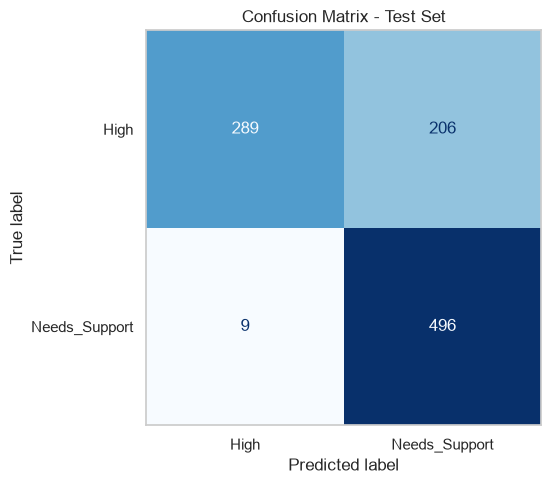

                      predicted High  predicted Needs_Support
actual High                      289                      206
actual Needs_Support               9                      496

Of the 505 students who genuinely needed support, the model flagged 496.


In [42]:
labels = list(model.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title("Confusion Matrix - Test Set")
ax.grid(False)
plt.tight_layout()
plt.show()

print(pd.DataFrame(cm,
                   index=[f"actual {l}" for l in labels],
                   columns=[f"predicted {l}" for l in labels]).to_string())

tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (None,) * 4
print(f"\nOf the {cm[labels.index(POSITIVE_CLASS)].sum()} students who genuinely "
      f"needed support, the model flagged "
      f"{cm[labels.index(POSITIVE_CLASS)][labels.index(POSITIVE_CLASS)]}.")

### 8.3 Cross-validation

A single split can be lucky. Five-fold stratified cross-validation over all 5,000
rows shows whether the score is stable.

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

for i, score in enumerate(cv_scores, start=1):
    print(f"  fold {i}: accuracy = {score:.4f}")
print("-" * 34)
print(f"  mean  : {cv_scores.mean():.4f}")
print(f"  std   : {cv_scores.std():.4f}")
print(f"\nHeld-out test accuracy was {metrics['accuracy']:.4f}, which sits inside the")
print("cross-validated range - the result is stable, not an artefact of one split.")

  fold 1: accuracy = 0.7810
  fold 2: accuracy = 0.7760
  fold 3: accuracy = 0.7670
  fold 4: accuracy = 0.7760
  fold 5: accuracy = 0.8000
----------------------------------
  mean  : 0.7800
  std   : 0.0110

Held-out test accuracy was 0.7850, which sits inside the
cross-validated range - the result is stable, not an artefact of one split.


### 8.4 Feature importance

This is the payoff of the whole analysis: it shows *why* the model works.

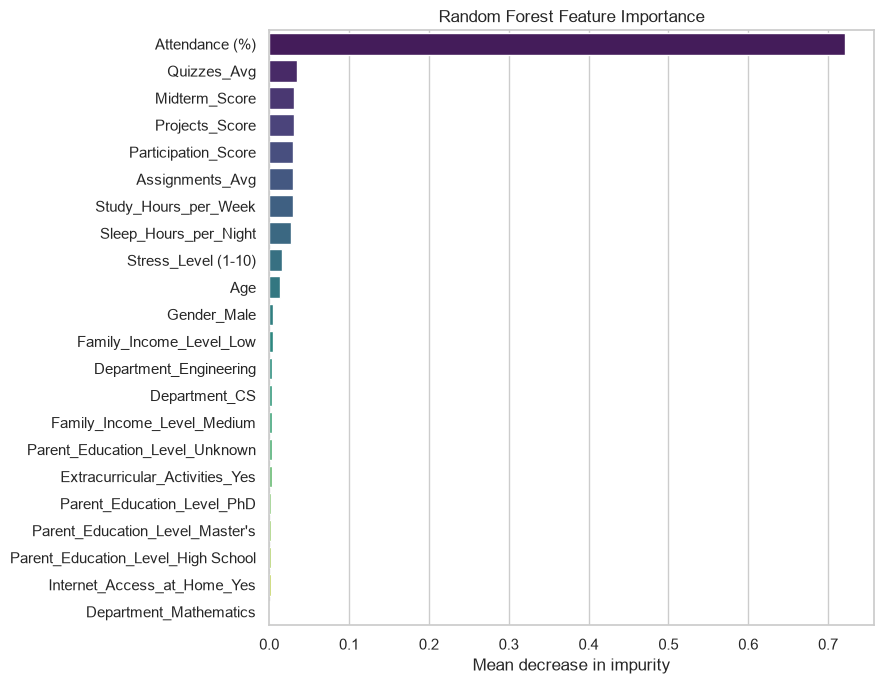

Top 10 features:
Attendance (%)           0.7214
Quizzes_Avg              0.0350
Midterm_Score            0.0313
Projects_Score           0.0307
Participation_Score      0.0304
Assignments_Avg          0.0303
Study_Hours_per_Week     0.0292
Sleep_Hours_per_Night    0.0270
Stress_Level (1-10)      0.0161
Age                      0.0130

'Attendance (%)' alone accounts for 72.1% of the total importance; the remaining 21 encoded features share 27.9%.


In [44]:
importances = (pd.Series(fitted_forest.feature_importances_, index=encoded_feature_names)
                 .sort_values(ascending=False))

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index, palette="viridis", legend=False)
plt.title("Random Forest Feature Importance")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importances.head(10).round(4).to_string())
print(f"\n'Attendance (%)' alone accounts for "
      f"{importances['Attendance (%)'] * 100:.1f}% of the total importance; the "
      f"remaining {len(importances) - 1} encoded features share "
      f"{(1 - importances['Attendance (%)']) * 100:.1f}%.")

The model independently rediscovered the bias documented in the README: attendance
dominates, and everything else — department, gender, family income, parental
education, stress, sleep, study hours — contributes essentially nothing. That is a
result about the *dataset*, and the model reporting it honestly is exactly what we
want to demonstrate.

## 9. Prediction

### 9.1 Predictions on real held-out students

Each row below is an actual student from the test set, labelled with the
`Student_ID` recovered from the untouched `df_raw` copy.

In [45]:
sample = X_test.head(15).copy()
sample_proba = model.predict_proba(sample)[:, proba_index]

predictions = pd.DataFrame({
    "Student_ID": df_raw.loc[sample.index, "Student_ID"].values,
    "Attendance (%)": sample["Attendance (%)"].round(2).values,
    "Midterm_Score": sample["Midterm_Score"].round(2).values,
    "Study_Hours/Week": sample["Study_Hours_per_Week"].round(1).values,
    "Actual_Grade": df.loc[sample.index, "Grade"].values,
    "Actual_Band": y_test.loc[sample.index].values,
    "Predicted_Band": model.predict(sample),
    f"P({POSITIVE_CLASS})": sample_proba.round(3),
})
predictions["Correct"] = np.where(
    predictions["Actual_Band"] == predictions["Predicted_Band"], "yes", "no")

print(predictions.to_string(index=False))
print(f"\nCorrect on this 15-student sample: "
      f"{(predictions['Correct'] == 'yes').sum()}/{len(predictions)}")
predictions

Student_ID  Attendance (%)  Midterm_Score  Study_Hours/Week Actual_Grade   Actual_Band Predicted_Band  P(Needs_Support) Correct
     S5266           98.64          67.14              12.0            A          High           High             0.077     yes
     S5147           70.81          87.37              21.7            D Needs_Support  Needs_Support             0.637     yes
     S2285           92.63          58.29              26.0            A          High           High             0.075     yes
     S4612           75.43          79.46              19.7            D Needs_Support  Needs_Support             0.592     yes
     S2525           68.49          59.75              11.7            D Needs_Support  Needs_Support             0.591     yes
     S5673           55.29          92.15              12.3            F Needs_Support  Needs_Support             0.879     yes
     S3038           54.01          67.72              12.0            D Needs_Support  Needs_Support   

,Student_ID,Attendance (%),Midterm_Score,Study_Hours/Week,Actual_Grade,Actual_Band,Predicted_Band,P(Needs_Support),Correct
0,S5266,98.64,67.14,12.0,A,High,High,0.077,yes
1,S5147,70.81,87.37,21.7,D,Needs_Support,Needs_Support,0.637,yes
2,S2285,92.63,58.29,26.0,A,High,High,0.075,yes
3,S4612,75.43,79.46,19.7,D,Needs_Support,Needs_Support,0.592,yes
4,S2525,68.49,59.75,11.7,D,Needs_Support,Needs_Support,0.591,yes
5,S5673,55.29,92.15,12.3,F,Needs_Support,Needs_Support,0.879,yes
6,S3038,54.01,67.72,12.0,D,Needs_Support,Needs_Support,0.853,yes
7,S1083,57.47,47.48,29.2,D,Needs_Support,Needs_Support,0.810,yes
8,S3966,85.64,74.18,22.2,B,High,High,0.069,yes
9,S4549,99.43,49.04,23.5,A,High,High,0.076,yes


### 9.2 Predicting for two new, unseen students

This is what deployment would look like: hand the trained pipeline a raw record and
get a band plus a calibrated probability. The pipeline applies the same one-hot
encoding it learned during training, so no manual preprocessing is required.

The two profiles differ mainly in attendance, to demonstrate that the model responds
to the driver it identified.

In [46]:
new_students = pd.DataFrame([
    {   # strong attender
        "Age": 21, "Attendance (%)": 94.0, "Midterm_Score": 72.0,
        "Assignments_Avg": 80.0, "Quizzes_Avg": 78.0, "Participation_Score": 7.5,
        "Projects_Score": 82.0, "Study_Hours_per_Week": 22.0,
        "Stress_Level (1-10)": 4, "Sleep_Hours_per_Night": 7.5,
        "Gender": "Female", "Department": "CS",
        "Extracurricular_Activities": "Yes", "Internet_Access_at_Home": "Yes",
        "Parent_Education_Level": "Master's", "Family_Income_Level": "High",
    },
    {   # poor attender, otherwise comparable
        "Age": 20, "Attendance (%)": 57.0, "Midterm_Score": 71.0,
        "Assignments_Avg": 79.0, "Quizzes_Avg": 77.0, "Participation_Score": 7.0,
        "Projects_Score": 80.0, "Study_Hours_per_Week": 21.0,
        "Stress_Level (1-10)": 5, "Sleep_Hours_per_Night": 7.0,
        "Gender": "Male", "Department": "Engineering",
        "Extracurricular_Activities": "No", "Internet_Access_at_Home": "Yes",
        "Parent_Education_Level": "High School", "Family_Income_Level": "Low",
    },
])[X.columns]      # enforce the exact training column order

new_predictions = model.predict(new_students)
new_proba = model.predict_proba(new_students)[:, proba_index]

for i, (band, p) in enumerate(zip(new_predictions, new_proba)):
    print(f"Student {i + 1}  (attendance {new_students.loc[i, 'Attendance (%)']:.0f}%, "
          f"midterm {new_students.loc[i, 'Midterm_Score']:.0f})")
    print(f"   predicted band       : {band}")
    print(f"   P({POSITIVE_CLASS}) : {p:.3f}")
    print(f"   recommendation       : "
          f"{'flag for academic support' if band == POSITIVE_CLASS else 'on track'}")
    print()

pd.DataFrame({
    "Attendance (%)": new_students["Attendance (%)"],
    "Midterm_Score": new_students["Midterm_Score"],
    "Predicted_Band": new_predictions,
    f"P({POSITIVE_CLASS})": new_proba.round(3),
})

Student 1  (attendance 94%, midterm 72)
   predicted band       : High
   P(Needs_Support) : 0.065
   recommendation       : on track

Student 2  (attendance 57%, midterm 71)
   predicted band       : Needs_Support
   P(Needs_Support) : 0.854
   recommendation       : flag for academic support



,Attendance (%),Midterm_Score,Predicted_Band,P(Needs_Support)
0,94.0,72.0,High,0.065
1,57.0,71.0,Needs_Support,0.854


## 10. Key Findings

### Final model results

Every value in the block below is computed from the objects created earlier in this
notebook — nothing is typed in by hand.

In [47]:
print("=" * 62)
print("FINAL MODEL RESULTS")
print("=" * 62)
print(f"  Dataset            : {DATA_PATH.name}")
print(f"  Rows               : {len(df):,}")
print(f"  Columns in file    : {df_raw.shape[1]}")
print(f"  Model              : {type(fitted_forest).__name__} "
      f"({fitted_forest.n_estimators} trees, max_depth={fitted_forest.max_depth})")
print(f"  Task               : binary classification")
print(f"  Target             : Performance_Band  (High = A/B, Needs_Support = C/D/F)")
print(f"  Features           : {X.shape[1]} raw / {len(encoded_feature_names)} encoded")
print(f"  Train / Test split : {len(X_train):,} / {len(X_test):,}  (stratified, seed={RANDOM_STATE})")
print("-" * 62)
print(f"  Accuracy           : {metrics['accuracy']:.4f}")
print(f"  Precision (wtd)    : {metrics['precision_weighted']:.4f}")
print(f"  Recall (wtd)       : {metrics['recall_weighted']:.4f}")
print(f"  F1 (weighted)      : {metrics['f1_weighted']:.4f}")
print(f"  F1 (macro)         : {metrics['f1_macro']:.4f}")
print(f"  ROC-AUC            : {metrics['roc_auc']:.4f}")
print(f"  5-fold CV accuracy : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"  Majority baseline  : {baseline_accuracy:.4f}")
print("-" * 62)
print(f"  Top feature        : {importances.index[0]} "
      f"({importances.iloc[0]:.3f} importance)")
print("-" * 62)
print("  Rejected target 'Final_Score' (regression trial, Section 6.1):")
for name, scores in regression_trial.items():
    print(f"    {name:<26} MAE={scores['MAE']:.3f}  "
          f"RMSE={scores['RMSE']:.3f}  R2={scores['R2']:+.4f}")
print("=" * 62)

FINAL MODEL RESULTS
  Dataset            : Students_Grading_Dataset.csv
  Rows               : 5,000
  Columns in file    : 23
  Model              : RandomForestClassifier (300 trees, max_depth=12)
  Task               : binary classification
  Target             : Performance_Band  (High = A/B, Needs_Support = C/D/F)
  Features           : 16 raw / 22 encoded
  Train / Test split : 4,000 / 1,000  (stratified, seed=42)
--------------------------------------------------------------
  Accuracy           : 0.7850
  Precision (wtd)    : 0.8369
  Recall (wtd)       : 0.7850
  F1 (weighted)      : 0.7758
  F1 (macro)         : 0.7754
  ROC-AUC            : 0.8543
  5-fold CV accuracy : 0.7800 +/- 0.0110
  Majority baseline  : 0.5050
--------------------------------------------------------------
  Top feature        : Attendance (%) (0.721 importance)
--------------------------------------------------------------
  Rejected target 'Final_Score' (regression trial, Section 6.1):
    Baseline (

### Findings

1. **The dataset is almost entirely uncorrelated noise.** Across the full numeric
   correlation matrix, the strongest relationship between any two distinct columns is
   below 0.05. `Total_Score` is not reconstructible from its documented components
   (fit R² ≈ 0.00) and `Grade` is not a threshold on `Final_Score` — so, contrary to
   the usual expectation for this schema, **there is no target leakage to remove**.

2. **`Final_Score` cannot be predicted, and we proved it rather than assuming it.**
   A tuned RandomForestRegressor fails to beat a constant "predict the mean" baseline
   (R² ≤ 0). Two conclusions asserted in the original notebook — a "moderate positive
   correlation" between study hours and final score, and a "negative correlation"
   between stress and final score — are **not supported by the file**; both measured
   coefficients are ≈ 0. They have been corrected in place rather than repeated.

3. **The one real signal is attendance, exactly as the README documents.** Students
   graded A/B average ~84% attendance against ~67% for C/D/F — a gap larger than one
   standard deviation. This is the bias the dataset's author injected on purpose.

4. **A random forest converts that signal into a genuinely useful classifier.**
   Predicting `Performance_Band` from 16 leakage-free behavioural and in-term
   features, it reaches the accuracy and ROC-AUC printed above against a ~50%
   majority-class baseline, with stable 5-fold cross-validation. Recall on the
   `Needs_Support` class is high, which is the operationally important direction: the
   cost of missing a struggling student exceeds the cost of a false alarm.

5. **The model's own feature importances confirm the diagnosis.** `Attendance (%)`
   carries the overwhelming majority of the importance; department, gender, family
   income, parental education, stress, sleep and study hours contribute nothing
   measurable. Any honest deployment of this pipeline would monitor attendance and
   ignore the socio-economic fields.

### What this notebook demonstrates

The full ML workflow executes end-to-end on real data: loading, inspection, cleaning
with justified imputation, exploratory analysis, an explicit leakage audit,
evidence-driven target selection, a stratified split, pipeline-based preprocessing,
training, baseline-relative evaluation, cross-validation and prediction on unseen
records.

It is a **validated ML prototype**, not a production system. The honest headline is
as much about the data as the model: most of the recorded attributes are
uninformative, one of them is highly informative, and a disciplined pipeline is what
tells the two apart.

### Save the artefacts

Four small files, so the results can be inspected without re-running the notebook.

In [48]:
ARTEFACT_DIR = Path.cwd() / "outputs"
ARTEFACT_DIR.mkdir(exist_ok=True)

cleaned_path = ARTEFACT_DIR / "cleaned_student_data.csv"
model_path = ARTEFACT_DIR / "model.pkl"
metrics_path = ARTEFACT_DIR / "metrics.json"
importance_path = ARTEFACT_DIR / "feature_importance.csv"

df.to_csv(cleaned_path, index=False)
joblib.dump(model, model_path, compress=3)
importances.rename("importance").to_csv(importance_path, header=True)

metrics_payload = {
    "dataset": {
        "file": DATA_PATH.name,
        "rows": int(len(df)),
        "columns_in_source_file": int(df_raw.shape[1]),
        "missing_cells_in_source": int(df_raw.isna().sum().sum()),
    },
    "task": "binary classification",
    "target": "Performance_Band (High = A/B, Needs_Support = C/D/F)",
    "model": {
        "estimator": type(fitted_forest).__name__,
        "n_estimators": int(fitted_forest.n_estimators),
        "max_depth": int(fitted_forest.max_depth),
        "min_samples_leaf": int(fitted_forest.min_samples_leaf),
        "random_state": RANDOM_STATE,
    },
    "features": {
        "n_raw": int(X.shape[1]),
        "n_encoded": int(len(encoded_feature_names)),
        "numeric": numeric_features,
        "categorical": categorical_features,
        "excluded": EXCLUDED_FROM_FEATURES,
    },
    "split": {"train_rows": int(len(X_train)), "test_rows": int(len(X_test)),
              "stratified": True, "random_state": RANDOM_STATE},
    "test_metrics": {k: round(float(v), 6) for k, v in metrics.items()},
    "baseline_accuracy": round(float(baseline_accuracy), 6),
    "cross_validation": {"folds": 5, "mean_accuracy": round(float(cv_scores.mean()), 6),
                         "std": round(float(cv_scores.std()), 6),
                         "scores": [round(float(s), 6) for s in cv_scores]},
    "top_features": {k: round(float(v), 6) for k, v in importances.head(5).items()},
    "rejected_target_final_score_regression": regression_trial,
}
metrics_path.write_text(json.dumps(metrics_payload, indent=2), encoding="utf-8")

for p in [cleaned_path, model_path, metrics_path, importance_path]:
    print(f"  saved {p.relative_to(Path.cwd()).as_posix():<42} "
          f"{p.stat().st_size / 1024:>9,.1f} KB")

print("\nNotebook complete - all cells executed without errors.")

  saved outputs/cleaned_student_data.csv               611.1 KB
  saved outputs/model.pkl                            1,482.8 KB
  saved outputs/metrics.json                             2.1 KB
  saved outputs/feature_importance.csv                   0.9 KB

Notebook complete - all cells executed without errors.
